In [14]:
! python joseph_quantitative_metrics.py --model_checkpoint "weights/Experiment2_NoSR_FFT_3001.pth" --model_version "NoSR" --eval_data "/project/vil_baek/data/physics/PARCTorch/HMX/test" --min_max_path "/sfs/gpfs/tardis/home/pdy2bw/Research/LatentPARC_new/LatentPARC/latent_parc/PARCtorch/PARCtorch/data/hmx_min_max.json"

INFO:root:Using device: cuda
INFO:root:Model architecture built.
INFO:root:Model weights loaded and set to evaluation mode.
INFO:root:Starting data validation...
INFO:root:Validating .npy files...
Validating files: 100%|█████████████████████████| 32/32 [00:01<00:00, 23.65it/s]
INFO:root:Data validation completed successfully.
INFO:root:Preparing dataset samples...
Listing samples: 100%|█████████████████████████| 32/32 [00:00<00:00, 502.12it/s]
INFO:root:Total samples in dataset: 32
INFO:root:Total evaluation samples: 32
Normalization keys: ['channel_min', 'channel_max']
INFO:root:Temperature (T) RMSE: 241.3388910879523
Temperature (T) RMSE: 241.3388910879523
INFO:root:Pressure (P) RMSE: 2170101667.3106127
Pressure (P) RMSE: 2170101667.3106127
INFO:root:Hotspot Temperature RMSE (T_hs): 590.8079687166285
Hotspot Temperature RMSE (T_hs): 590.8079687166285
INFO:root:Hotspot Area RMSE (A_hs): 0.00792556924421135
Hotspot Area RMSE (A_hs): 0.00792556924421135
INFO:root:Hotspot Temperature Rat

In [11]:
import numpy as np
import torch
import json
import matplotlib.pyplot as plt

In [27]:
def qoi(arrs, json_file): 
    total_area = arrs.shape[1] * arrs.shape[2]
    dt = 0.17
    
    with open(json_file, "r") as f:
        stats = json.load(f)

    cmin = stats["channel_min"][0]
    cmax = stats["channel_max"][0]

    arrs = np.copy(arrs)
    arrs = arrs * (cmax - cmin) + cmin

    hotspot_thresh = 875. 

    mask = arrs > hotspot_thresh
    hotspot_sum = np.sum(np.where(mask, arrs, 0.0), axis=(1, 2))
    hotspot_count = np.sum(mask, axis=(1, 2))
    
    hs_t = np.divide(hotspot_sum, hotspot_count, out=np.zeros(hotspot_count.shape, dtype=float), where=hotspot_count > 0 ) # to avoid NaN when there's no hotpsot 
    hs_a = hotspot_count / total_area

    hs_tdot = [ (hs_t[x+1] - hs_t[x]) / dt for x in range(len(hs_t)-1)]
    hs_adot = [ (hs_a[x+1] - hs_a[x]) / dt for x in range(len(hs_t)-1)]

    return hs_t, hs_a, hs_tdot, hs_adot

In [29]:
json_file="/sfs/gpfs/tardis/home/pdy2bw/Research/LatentPARC_new/LatentPARC/latent_parc/PARCtorch/PARCtorch/data/hmx_min_max.json"

# Example: load later and use with your function
pred_arrs = np.load("phongSR_arr.npy")
GT_arrs = np.load("GT_arr.npy")

pred_qois = qoi(pred_arrs, json_file)
GT_qois = qoi(GT_arrs, json_file)

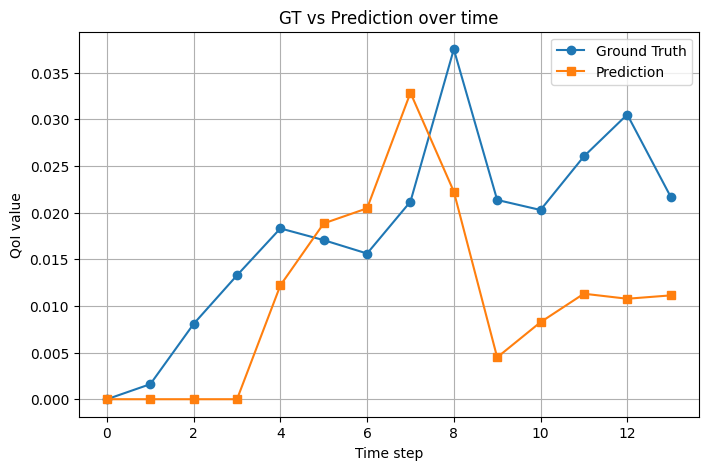

In [36]:
i = 3

gt = GT_qois[i]
pred = pred_qois[i]

t = np.arange(len(gt))  # assumes both are length 15

plt.figure(figsize=(8, 5))

plt.plot(t, gt, marker='o', label='Ground Truth')
plt.plot(t, pred, marker='s', label='Prediction')

plt.xlabel("Time step")
plt.ylabel("QoI value")
plt.title("GT vs Prediction over time")
plt.legend()
plt.grid(True)

plt.show()